# Connectome-Constrained Reservoirs

### Does topology shape cognition?

*An investigation into how biologically-derived recurrent
connectivity influences computation in reservoir networks.*

---

Matthys du Toit · Imperial College London · 11.05.2026

<img src="images/BASIRA_lab_logo.png" width="30%">

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import reservoirpy as rpy

# just a little tweak to center the plots, nothing to worry about
from IPython.core.display import HTML
HTML("""
<style>
.img-center {
    display: block;
    margin-left: auto;
    margin-right: auto;
    }
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
    }
</style>
""")

rpy.set_seed(42)

## What is Reservoir Computing?

<!-- - A **fixed, randomly-initialised recurrent network** (the *reservoir*) projects input into a high-dimensional dynamical state.
- Only a **simple linear readout** is trained.
- Cheap to train (no backprop through time), excellent on temporal tasks, biologically plausible. -->

- RC conceptualizes how a brain-like system operates, with a core three-layer architecure:
    1. **Input (sensing) layer:** receives information and performs some pre-processing
    2. **Middle (processing) layer:** defined by some nonlinear recurrent dynamics with input signals acting as stimulus
    3. **Output (readout) layer:** recombines signals from the processing layer to produce the final output

- Echo State Networks (ESNs) (Jaeger, 2001) are one of the simplest recurrent neural network architecture RC has to offer. They are built using two components: a **reservoir** and a **readout**.

<center><img src="./images/esn.svg" width="55%"></center>

## The Echo State Network

- The **reservoir** is a pool of artificial rate neurons randomly connected to their inputs and to themselves. 
    - Therefore, they are a genuine recurrent neural network similar to those which can be found in the field of machine learning in general. 
    - However, **none of the connections inside the reservoir are trained**. They are randomly initialized following several hyperparameters.

- The random high dimensional activation vector of the reservoir is then fed to the **readout**, a single layer of neurons in charge with decoding the reservoir activations in order to perform a task. 
    - The connections between the readout and the reservoir are the only **learned** connections in an ESN. 
    - In consequence, there is no need for complicated learning algorithm such as back-propagation of error to train them: a simple linear regression can make it.

- Activations of the readout might also be fed back to the reservoir. This is called a **feedback** connection. This is an optional feature that can help tame the reservoir neurons activities.

<!-- ### The reservoir state equation:

$$x(t+1) = (1-\alpha)\, x(t) + \alpha \tanh\!\left(W_{in}\, u(t+1) + W\, x(t)\right)$$

- $\alpha$ — leak rate
- $W$ — recurrent matrix (**the focus of this work**)
- $\tanh$ — nonlinearity

Today we'll swap out $W$ for biological connectomes. -->

### The reservoir state equation:

$$x(t+1) = (1-\alpha)\, x(t) + \alpha \tanh\!\left(W_{in}\, u(t+1) + W\, x(t)\right)$$

- $\alpha$ — leak rate
- $W$ — recurrent matrix (**the focus of this work**)
- $\tanh$ — nonlinearity

Today we'll swap out $W$ for biological connectomes.

## Training: only the readout

After collecting reservoir states $X$ over a training run, the readout is fit by ridge regression:

$$W_{out} = Y X^\top \left(X X^\top + \lambda I\right)^{-1}$$

This is what makes RC cheap — a single closed-form linear regression on the collected states.


## Reservoir Computing for chaotic timeseries forecasting

### A minimal ReservoirPy example

**Mackey-Glass timeseries**

Mackey-Glass equation are a set of delayed differential equations
describing the temporal behavior of different physiological signal,
for example, the relative quantity of mature blood cells over time.

The equations are defined as:

$$
\frac{dP(t)}{dt} = \frac{a P(t - \tau)}{1 + P(t - \tau)^n} - bP(t)
$$

where $a = 0.2$, $b = 0.1$, $n = 10$, and the time delay $\tau = 17$.
$\tau$ controls the chaotic behavior of the equations (the higher it is,
the more chaotic the timeseries becomes.
$\tau=17$ already gives good chaotic results.)


In [2]:
from reservoirpy.datasets import mackey_glass
from reservoirpy.observables import nrmse, rsquare

timesteps = 2510
tau = 17
X = mackey_glass(timesteps, tau=tau)

# rescale between -1 and 1
X = 2 * (X - X.min()) / (X.max() - X.min()) - 1

In [3]:
def plot_mackey_glass(X, sample, tau):

    fig = plt.figure(figsize=(13, 5))
    N = sample

    ax = plt.subplot((121))
    t = np.linspace(0, N, N)
    for i in range(N-1):
        ax.plot(t[i:i+2], X[i:i+2], color=plt.cm.magma(255*i//N), lw=1.0)

    plt.title(f"Timeseries - {N} timesteps")
    plt.xlabel("$t$")
    plt.ylabel("$P(t)$")

    ax2 = plt.subplot((122))
    ax2.margins(0.05)
    for i in range(N-1):
        ax2.plot(X[i:i+2], X[i+tau:i+tau+2], color=plt.cm.magma(255*i//N), lw=1.0)

    plt.title(f"Phase diagram: $P(t) = f(P(t-\\tau))$")
    plt.xlabel("$P(t-\\tau)$")
    plt.ylabel("$P(t)$")

    plt.tight_layout()
    plt.show()

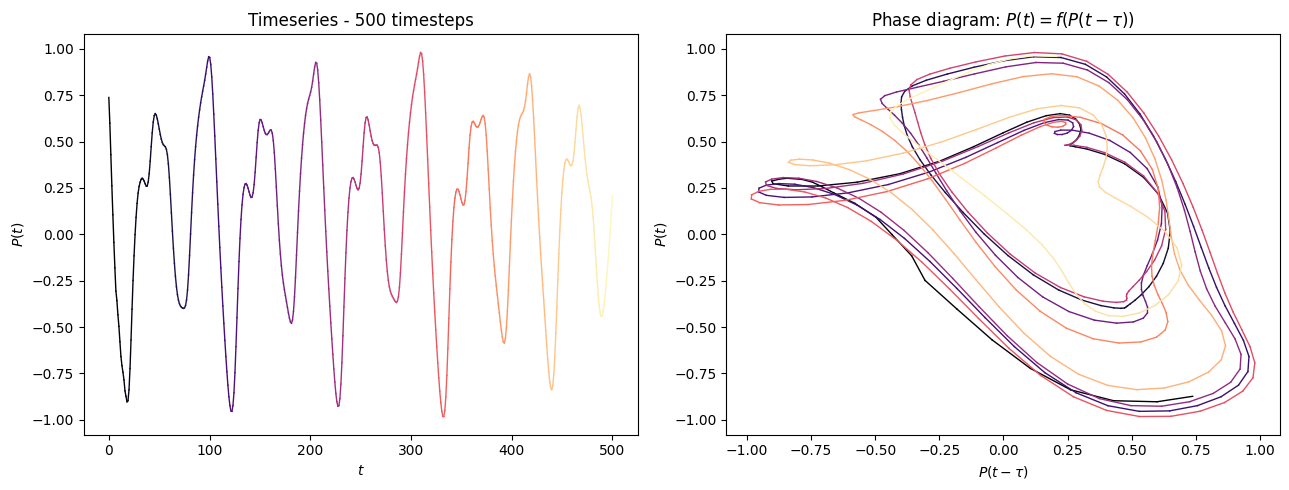

In [4]:
plot_mackey_glass(X, 500, tau)

- Not completely unpredictable... (not random)
- ...but not easily predictable (not periodic)
- Similar to ECG rhythms, stocks, weather...

## Can our Echo State Network forecast 10 timesteps ahead?

**Task: Predict $P(t + 10)$ given $P(t)$**

Data preprocessing:

In [5]:
def plot_train_test(X_train, y_train, X_test, y_test):
    sample = 500
    test_len = X_test.shape[0]
    fig = plt.figure(figsize=(15, 5))
    plt.plot(np.arange(0, 500), X_train[-sample:], label="Training data")
    plt.plot(np.arange(0, 500), y_train[-sample:], label="Training ground truth")
    plt.plot(np.arange(500, 500+test_len), X_test, label="Testing data")
    plt.plot(np.arange(500, 500+test_len), y_test, label="Testing ground truth")
    plt.legend()
    plt.show()

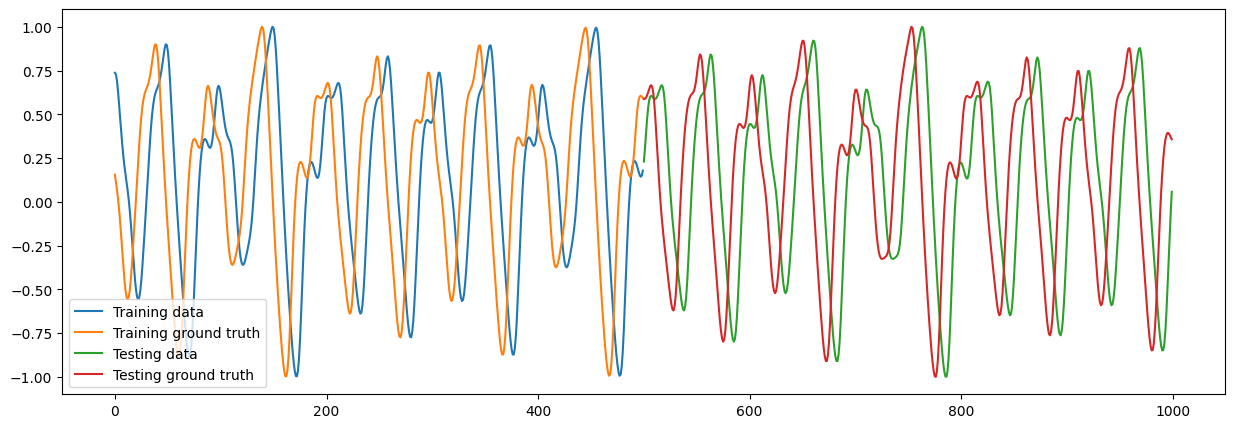

In [6]:
from reservoirpy.datasets import to_forecasting

x, y = to_forecasting(X, forecast=10)
X_train1, y_train1 = x[:2000], y[:2000]
X_test1, y_test1 = x[2000:], y[2000:]

plot_train_test(X_train1, y_train1, X_test1, y_test1)

## Building our first ESN with Reservoirpy

In [7]:
units = 100
leak_rate = 0.3
spectral_radius = 1.25
input_scaling = 1.0
connectivity = 0.1
input_connectivity = 0.2
regularization = 1e-8
seed = 1234

In [8]:
def reset_esn():
    from reservoirpy.nodes import Reservoir, Ridge

    reservoir = Reservoir(units, input_scaling=input_scaling, sr=spectral_radius,
                          lr=leak_rate, rc_connectivity=connectivity,
                          input_connectivity=input_connectivity, seed=seed)
    readout   = Ridge(ridge=regularization, output_dim=1)

    return reservoir >> readout

In [9]:
from reservoirpy.nodes import Reservoir, Ridge

reservoir = Reservoir(units, input_scaling=input_scaling, sr=spectral_radius,
                      lr=leak_rate, rc_connectivity=connectivity,
                      input_connectivity=input_connectivity, seed=seed)

readout   = Ridge(ridge=regularization, output_dim=1)

esn = reservoir >> readout

### ESN training & testing:

Training is performed *offline*: it happens only once on the whole dataset.

In [10]:
esn = esn.fit(X_train1, y_train1)

In [11]:
def plot_results(y_pred, y_test, sample=500):

    fig = plt.figure(figsize=(15, 7))
    plt.subplot(211)
    plt.plot(np.arange(sample), y_pred[:sample], lw=3, label="ESN prediction")
    plt.plot(np.arange(sample), y_test[:sample], linestyle="--", lw=2, label="True value")
    plt.plot(np.abs(y_test[:sample] - y_pred[:sample]), label="Absolute deviation")

    plt.legend()
    plt.show()

In [12]:
y_pred1 = esn.run(X_test1)

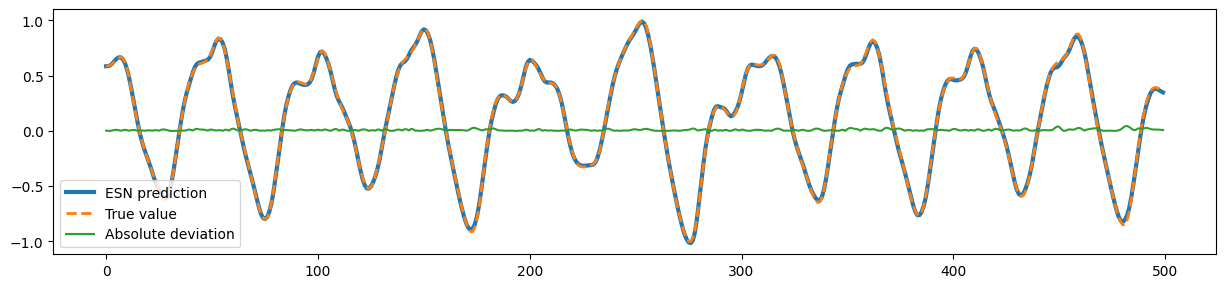

In [13]:
plot_results(y_pred1, y_test1)

$R^2$ and NRMSE :

In [14]:
print(f"R2 = {rsquare(y_test1, y_pred1):.5}, NRMSE = {nrmse(y_test1, y_pred1):.5}")

R2 = 0.99949, NRMSE = 0.0056372


### The two key hyperparameters:

- **Spectral radius** `sr`: largest absolute eigenvalue of $W$. Controls the timescale of reservoir dynamics. Near 1 = "edge of chaos" = rich dynamics. **This is the critical confound we'll control.**
- **Leak rate** `lr` ($\alpha$): how much of the previous state carries over. Lower = longer memory, slower dynamics.


## From random to biological

- Standard ESNs use a **randomly-generated** `W`. But the brain doesn't.
- *What if we replace `W` with the connectivity of a real nervous system?*
- *Does the topology of biological recurrent networks confer computational advantages over random baselines?*

<center><img src="./images/RC-evolution.png" width="55%"></center>

Suárez, L.E., Mihalik, A., Milisav, F. et al. Connectome-based reservoir computing with the conn2res toolbox. Nat Commun 15, 656 (2024). https://doi.org/10.1038/s41467-024-44900-4


## Today's experiment

**Question:** Does the *C. elegans* connectome (a real biological recurrent network) yield a reservoir with different memory capacity than random baselines, when spectral radius is controlled?

<div style="display: flex; justify-content: center; align-items: center; gap: 20px;">
  <img src="./images/WormWideWeb.png" style="height: 300px;">
  <img src="./images/Celegans.png" style="height: 300px;">
</div>

**Design:**
- Four reservoir conditions: random Gaussian, Erdős–Rényi, degree-preserving rewire, *C. elegans* connectome
- Same $N$, same spectral radius, same input scaling
- Measure **memory capacity** (Jaeger, 2001)
- Sweep spectral radius $\in \{0.8, 0.95, 1.1\}$
- 10 seeds for stochastic conditions


## Data: the *C. elegans* connectome

**Source.** Cook et al. (2019), *Whole-animal connectomes of both
Caenorhabditis elegans sexes*. Nature 571, 63–71.

- Downloaded from [WormWiring](https://wormwiring.org/pages/adjacency.html) (SI 5, corrected July 2020).
- **v1**: hermaphrodite chemical synapse matrix, **binarised and symmetrised**.
- Gap junctions, weights, and direction deferred to v2.


In [15]:
# Setup: imports + global seed
import os
import time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from tqdm.auto import tqdm
from threadpoolctl import threadpool_limits

# Cap BLAS threads. On a many-core machine the default (1 thread per core)
# oversubscribes for our 300x300 problem and runs ~30x slower than necessary.
threadpool_limits(limits=2)

from reservoirpy.nodes import Reservoir, Ridge

GLOBAL_SEED = 0
np.random.seed(GLOBAL_SEED)

FIG_DIR = "./figures"
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})


/home/matthys/imperial/thesis/cognitive-connectomes/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
from pathlib import Path
REPO_ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent

In [17]:
DATA_PATH = REPO_ROOT / "data" / "cook2019_connectome.xlsx"

# Load the hermaphrodite chemical synapse adjacency matrix.
# header=2 and index_col=2 are correct for the corrected July 2020 file.
df = pd.read_excel(
    DATA_PATH,
    sheet_name="hermaphrodite chemical",
    header=2,
    index_col=2,
)

# Coerce all entries to numeric (some cells have text/whitespace) and zero NaN
df = df.apply(pd.to_numeric, errors='coerce').fillna(0)

# Keep only the square block where row and column labels match
common_labels = sorted(set(df.index.dropna()) & set(df.columns.dropna()))
adjacency_weighted = df.loc[common_labels, common_labels].values.astype(float)
neuron_names = list(common_labels)

# Binarise and symmetrise for v1
adjacency_binary = (adjacency_weighted > 0).astype(float)
adjacency_undirected = ((adjacency_binary + adjacency_binary.T) > 0).astype(float)

N = adjacency_undirected.shape[0]
n_edges = int(adjacency_undirected.sum() // 2)
density = n_edges / (N * (N - 1) / 2)

print(f"Loaded C. elegans hermaphrodite chemical connectome:")
print(f"  Nodes (N): {N}")
print(f"  Undirected edges: {n_edges}")
print(f"  Density: {density:.3%}")

# Sanity check: stop loudly if the loaded matrix is unexpected
assert N == 300, f"Expected 300 nodes, got {N}"
assert n_edges == 3019, f"Expected 3019 edges, got {n_edges}"


Loaded C. elegans hermaphrodite chemical connectome:
  Nodes (N): 300
  Undirected edges: 3019
  Density: 6.731%



**At a glance:** 300 neurons, 3019 undirected chemical-synapse edges (~6.7% density).

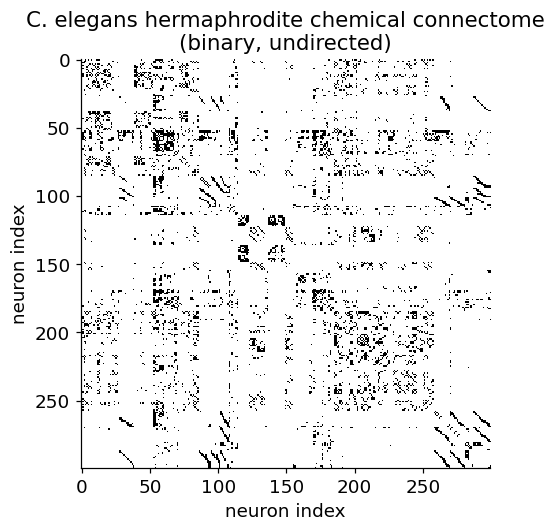

In [18]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(adjacency_undirected, cmap="binary", interpolation="nearest")
ax.set_title("C. elegans hermaphrodite chemical connectome\n(binary, undirected)")
ax.set_xlabel("neuron index"); ax.set_ylabel("neuron index")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "connectome_heatmap.png"))
plt.show()

### Graph statistics:

These numbers are the **targets** for the null models we build next:

| statistic           | value         |
|---------------------|---------------|
| nodes $N$           | 300           |
| undirected edges    | 3019          |
| density             | 6.7%          |
| mean degree         | 2·3019 / 300 ≈ 20.1 |


## Reservoir construction

We build each reservoir from an adjacency matrix, rescaled to a fixed target spectral radius. Same `lr`, same `input_scaling`, same `W_in` *statistics* across all conditions — only `W` differs.


In [19]:
def build_reservoir(adjacency, target_sr, leak_rate=1.0,
                    input_scaling=1.0, seed=0):
    """Build a ReservoirPy Reservoir from an adjacency matrix, rescaled to
    a target spectral radius.

    adjacency : (N, N) numpy array (dense).
    Returns a configured Reservoir node ready for use.
    """
    A = np.asarray(adjacency, dtype=float)
    if A.ndim != 2 or A.shape[0] != A.shape[1]:
        raise ValueError(f"adjacency must be square 2D; got {A.shape}")

    # Rescale to target spectral radius
    eigs = np.linalg.eigvals(A)
    current_sr = float(np.max(np.abs(eigs)))
    if current_sr < 1e-12:
        raise ValueError("Adjacency spectral radius ~0; cannot rescale.")
    W = A * (target_sr / current_sr)

    N_local = W.shape[0]

    # Per-seed input weights, same Bernoulli ±1 statistics across conditions
    rng = np.random.default_rng(seed)
    Win = rng.choice([-1.0, 1.0], size=(N_local, 1)) * input_scaling

    return Reservoir(W=W, Win=Win, lr=leak_rate, seed=seed)

## Null models: a topology ladder

Each successive null preserves more of the connectome's structure:

1. **Random Gaussian** — sparse i.i.d. Gaussian weights at the connectome's density.
2. **Erdős–Rényi** — uniformly random graph with the **same edge count**.
3. **Degree-preserving rewire** — `nx.double_edge_swap`, preserves the **exact degree sequence**.
4. **Connectome** — the real *C. elegans* matrix.

In [20]:
def random_gaussian(n, density, seed):
    """Sparse matrix with i.i.d. Gaussian entries at the given density."""
    rng = np.random.default_rng(seed)
    mask = rng.random((n, n)) < density
    np.fill_diagonal(mask, False)
    W = rng.normal(0.0, 1.0, size=(n, n)) * mask
    return W


def erdos_renyi(n, n_edges, seed):
    """Erdős–Rényi G(n, m): same edge count as the connectome."""
    G = nx.gnm_random_graph(n, n_edges, seed=seed)
    A = nx.to_numpy_array(G)
    return A


def degree_preserving_rewire(adjacency, seed, swap_factor=10):
    """Double-edge swap preserving exact degree sequence."""
    G = nx.from_numpy_array(adjacency)
    n_edges_local = G.number_of_edges()
    n_swaps = swap_factor * n_edges_local
    nx.double_edge_swap(G, nswap=n_swaps, max_tries=n_swaps * 10, seed=seed)
    A = nx.to_numpy_array(G)
    return A


## Memory capacity (Jaeger, 2001)

Feed white noise $u(t)$ into the reservoir and ask: how well can a linear readout reconstruct $u(t-k)$ from the reservoir state $x(t)$, as a function of the lag $k$?

$$\mathrm{MC} = \sum_{k=1}^{k_{\max}} r^2\!\left(\hat{u}_k(t),\, u(t-k)\right)$$

A single scalar that captures **how many timesteps of past input** the reservoir can hold.


In [21]:
def measure_memory_capacity(reservoir, T=3000, warmup=500, max_lag=50,
                            ridge_alpha=1e-6, seed=0):
    """Standard Jaeger MC. Returns (total_mc, mc_per_lag)."""
    rng = np.random.default_rng(seed)
    u = rng.uniform(-1.0, 1.0, size=(T, 1))

    if getattr(reservoir, "state", None) is not None:
        reservoir.reset()
    states = reservoir.run(u)  # (T, N)

    # Discard warmup
    S = states[warmup:]
    u_flat = u[warmup:, 0]
    n_local = S.shape[0]

    mc_per_lag = np.zeros(max_lag)
    for k in range(1, max_lag + 1):
        # Predict u(t-k) from x(t). Valid index range: t in [k, n_local-1].
        X = S[k:]                       # (n-k, N_units)
        y = u_flat[: n_local - k]       # (n-k,)
        XtX = X.T @ X
        N_units = X.shape[1]
        w = np.linalg.solve(XtX + ridge_alpha * np.eye(N_units), X.T @ y)
        pred = X @ w
        if np.std(pred) < 1e-12 or np.std(y) < 1e-12:
            mc_per_lag[k - 1] = 0.0
        else:
            r, _ = pearsonr(pred, y)
            mc_per_lag[k - 1] = r ** 2
    return float(mc_per_lag.sum()), mc_per_lag


## Sanity check

A random-Gaussian reservoir of $N{=}300$ at $sr{=}0.95$ should land in $\mathrm{MC} \approx 10\text{–}30$. If it doesn't, the indexing in the MC function is wrong.


In [22]:
# Sanity check: random Gaussian reservoir, MC at sr=0.95 should be 10-30
W_sanity = random_gaussian(N, density, seed=0)
res_sanity = build_reservoir(W_sanity, target_sr=0.95, leak_rate=1.0,
                             input_scaling=1.0, seed=0)
mc_sanity, _ = measure_memory_capacity(res_sanity, T=3000, warmup=500,
                                       max_lag=50, ridge_alpha=1e-6, seed=1)
print(f"Sanity-check MC (random Gaussian, sr=0.95): {mc_sanity:.2f}")
assert 5 < mc_sanity < 50, (
    f"MC sanity check failed: got {mc_sanity:.2f}, expected ~10-30. "
    "Indexing in measure_memory_capacity is probably wrong."
)
print("Sanity check passed.")


Sanity-check MC (random Gaussian, sr=0.95): 14.32
Sanity check passed.


## Running the experiment

Sweep $sr \in \{0.8, 0.95, 1.1\}$, four conditions, 10 seeds — measure MC for each.

### Results: mean MC by condition and spectral radius

In [23]:
conditions = ["random_gaussian", "erdos_renyi", "degree_rewire", "connectome"]
spectral_radii = [0.8, 0.95, 1.1]
n_seeds = 10

LEAK_RATE = 1.0
INPUT_SCALING = 1.0
T_MC, WARMUP, MAX_LAG, RIDGE_ALPHA = 3000, 500, 50, 1e-6

def make_adjacency(condition, seed):
    if condition == "random_gaussian":
        return random_gaussian(N, density, seed=seed)
    if condition == "erdos_renyi":
        return erdos_renyi(N, n_edges, seed=seed)
    if condition == "degree_rewire":
        return degree_preserving_rewire(adjacency_undirected, seed=seed)
    if condition == "connectome":
        return adjacency_undirected.copy()
    raise ValueError(condition)


results = []
t0 = time.time()

total_iters = len(conditions) * len(spectral_radii) * n_seeds
pbar = tqdm(total=total_iters, desc="experiments")
for condition in conditions:
    for sr in spectral_radii:
        for seed in range(n_seeds):
            adj = make_adjacency(condition, seed=seed)
            reservoir = build_reservoir(
                adj, target_sr=sr, leak_rate=LEAK_RATE,
                input_scaling=INPUT_SCALING, seed=seed,
            )
            mc, mc_per_lag = measure_memory_capacity(
                reservoir, T=T_MC, warmup=WARMUP, max_lag=MAX_LAG,
                ridge_alpha=RIDGE_ALPHA, seed=seed + 1000,
            )
            results.append({
                "condition": condition,
                "sr": sr,
                "seed": seed,
                "mc": mc,
                "mc_per_lag": mc_per_lag,
            })
            pbar.update(1)
pbar.close()

elapsed = time.time() - t0
results_df = pd.DataFrame(results)
print(f"Done in {elapsed:.1f} s ({elapsed/60:.2f} min). {len(results_df)} runs.")


experiments: 100%|██████████| 120/120 [00:55<00:00,  2.15it/s]

Done in 55.8 s (0.93 min). 120 runs.


In [24]:
summary = (
    results_df.groupby(["condition", "sr"])["mc"]
    .agg(["mean", "std"]).round(2).reset_index()
)
summary


,condition,sr,mean,std
0,connectome,0.80,6.48,0.15
1,connectome,0.95,7.26,0.24
2,connectome,1.10,8.19,0.33
3,degree_rewire,0.80,6.09,0.24
4,degree_rewire,0.95,6.89,0.35
5,degree_rewire,1.10,7.74,0.53
6,erdos_renyi,0.80,6.76,0.13
7,erdos_renyi,0.95,7.68,0.24
8,erdos_renyi,1.10,8.92,0.39
9,random_gaussian,0.80,13.64,0.18


## Memory capacity across topologies


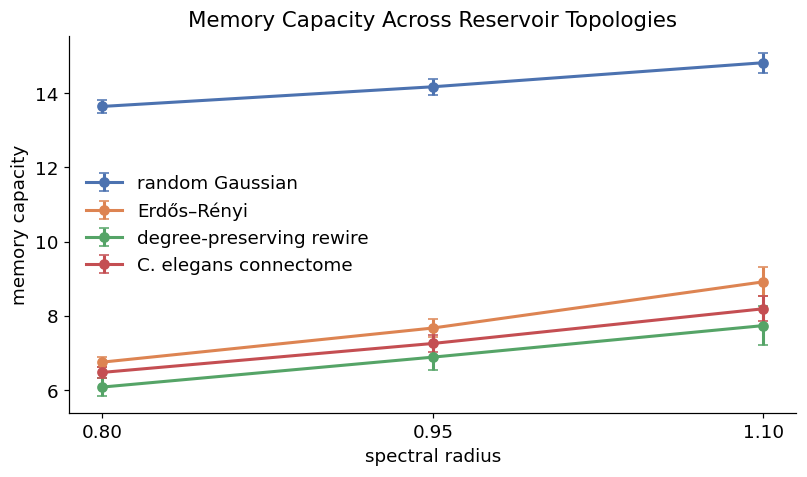

In [25]:
palette = {
    "random_gaussian": "#4c72b0",
    "erdos_renyi":     "#dd8452",
    "degree_rewire":   "#55a467",
    "connectome":      "#c44e52",
}
labels = {
    "random_gaussian": "random Gaussian",
    "erdos_renyi":     "Erdős–Rényi",
    "degree_rewire":   "degree-preserving rewire",
    "connectome":      "C. elegans connectome",
}

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for cond in conditions:
    sub = results_df[results_df["condition"] == cond]
    agg = sub.groupby("sr")["mc"].agg(["mean", "std"]).reset_index()
    ax.errorbar(
        agg["sr"], agg["mean"], yerr=agg["std"],
        marker="o", capsize=3, lw=2,
        color=palette[cond], label=labels[cond],
    )
ax.set_xlabel("spectral radius")
ax.set_ylabel("memory capacity")
ax.set_title("Memory Capacity Across Reservoir Topologies")
ax.set_xticks(spectral_radii)
ax.legend(loc="best")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "mc_vs_sr.png"))
plt.show()


## Memory decay by lag (sr = 0.95)


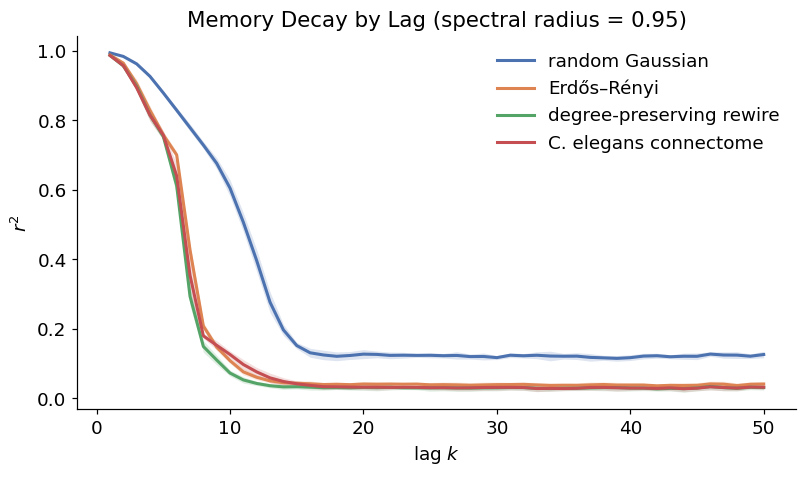

In [26]:
target_sr = 0.95
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for cond in conditions:
    sub = results_df[(results_df["condition"] == cond) &
                     (results_df["sr"] == target_sr)]
    stacked = np.vstack(sub["mc_per_lag"].values)  # (n_seeds, max_lag)
    mean = stacked.mean(axis=0)
    std = stacked.std(axis=0)
    lags = np.arange(1, MAX_LAG + 1)
    ax.plot(lags, mean, color=palette[cond], lw=2, label=labels[cond])
    ax.fill_between(lags, mean - std, mean + std,
                    color=palette[cond], alpha=0.18, lw=0)
ax.set_xlabel("lag $k$")
ax.set_ylabel(r"$r^2$")
ax.set_title(f"Memory Decay by Lag (spectral radius = {target_sr})")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "mc_decay.png"))
plt.show()


## Findings

The cell below prints the headline numbers; the slide below interprets them.


In [27]:
# Headline: connectome vs degree-rewire vs ER vs random Gaussian at sr=0.95
print("Mean MC at sr=0.95:")
for cond in conditions:
    vals = results_df[(results_df["condition"] == cond) &
                      (results_df["sr"] == 0.95)]["mc"]
    print(f"  {labels[cond]:30s} {vals.mean():6.2f} ± {vals.std():5.2f}")


Mean MC at sr=0.95:
  random Gaussian                 14.17 ±  0.22
  Erdős–Rényi                      7.68 ±  0.24
  degree-preserving rewire         6.89 ±  0.35
  C. elegans connectome            7.26 ±  0.24


## Interpretation

At sr = 0.95 (mean ± std across 10 seeds):

| condition                  | MC            |
|----------------------------|---------------|
| random Gaussian            | **14.17** ± 0.22 |
| Erdős–Rényi (binary)       | 7.68 ± 0.24   |
| degree-preserving rewire   | 6.89 ± 0.35   |
| *C. elegans* connectome    | 7.26 ± 0.24   |

- The **connectome is statistically indistinguishable from its degree-preserving null** (overlapping bars). Degree distribution captures most of the topology effect we measure here.
- The three **binary, unweighted** graphs (ER, rewire, connectome) cluster around MC ≈ 7. The **continuous-weighted random Gaussian** sits at ~14 — a confound to fix in v2 (we should compare against a *binary* random null too).
- MC rises with spectral radius across all conditions, as expected.

**Honest v1 read.** At this resolution, *C. elegans* topology is not a free lunch for linear memory.


## Caveats

- **Small $N$.** 300 nodes; effects may not generalise to larger connectomes.
- **Binary, undirected.** Throws away synaptic weights and direction.
- **Memory capacity is a thin slice of "cognition".** Doesn't probe nonlinearity, separation, or task-relevant computation.
- **One axis of dynamics.** We swept spectral radius; input scaling and leak rate held fixed.


## Next steps

- **Information processing capacity** (Dambre et al., 2012) — richer dynamical characterisation.
- **Weighted + directed** connectome.
- **Larger connectomes**: mouse mesoscale, human HCP.
- **Harder tasks**: sequential MNIST, delayed match-to-sample.
- **Stronger nulls**: modularity- and clustering-preserving rewires.


# Thanks

Code & slides: `cognitive-connectomes/presentations/01-cognitive-connectomes.ipynb`

Questions?
